# Plan your trip

In [1]:
import os
import sys
from dotenv import load_dotenv
import time
import pandas as pd
from warnings import filterwarnings
filterwarnings("ignore")
from IPython.display import Image

# Local application
import scripts.geocodage_villes
from scripts.meteo import meteo_villes
from scripts.scrape_hotels import scrape_booking
from scripts.fusion_chargement_s3 import generer_dataset_final, upload_dataset_final_s3
from scripts.rds_sql import base_sql
from scripts.cartes import visualiser_cartes_dataset_final
os.makedirs("data", exist_ok=True)

## 1 - Géocodage des villes

In [2]:
# Exécution du script geocode_ville.py
%run scripts/geocodage_villes.py

# Visualiser les données géocodées
df_geo = pd.read_csv("data/geocode_villes.csv")
display(df_geo.head())
print(f"{len(df_geo)} villes géocodées.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\geocode_villes.csv


,id_ville,ville,latitude,longitude
0,fb1372c111d5,Mont Saint Michel,48.635954,-1.511460
1,b1926dc4d399,Saint Malo,48.649518,-2.026041
2,5fd0187b51b2,Bayeux,49.276462,-0.702474
3,4e9b8cad09f6,Le Havre,49.493898,0.107973
4,e76e9773c33d,Rouen,49.440459,1.093966


35 villes géocodées.


## 2 - Données météo

In [3]:
# Exécution du script complet meteo.py
%run scripts/meteo.py

df_meteo = pd.read_csv("data/villes_meteo.csv")
display(df_meteo.head())
print(f"Données météo récupérées pour {len(df_meteo)} villes.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\villes_meteo.csv


,id_ville,nom_ville,temp_moy,ressenti,humidity_moy,prob_pluie_moy,uv_moy,meteo_score
0,eb1591916474,Montauban,12.0,11.5,72.3,41.0,0.8,38.9
1,4cc9af0bda9a,Collioure,14.1,13.4,72.6,433.0,0.9,29.9
2,6b599cb3b957,Ariege,7.6,6.9,66.4,220.0,1.0,28.4
3,6a5b4d7eaece,Marseille,13.5,13.1,80.6,551.0,0.8,27.8
4,43b3fa47f36a,Toulouse,11.9,11.4,73.4,200.0,0.9,27.3


Données météo récupérées pour 35 villes.


## 3 - Hotels

In [4]:
# Exécution du script complet scrape_hotels.py
%run scripts/meteo.py

df_hotels = pd.read_csv("data/hotels.csv")
display(df_hotels.head(10))
print(f"{len(df_hotels)} hôtels récupérés.")

Fichier CSV généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\villes_meteo.csv


,id,id_ville,ville,nom,url,note,latitude,longitude
0,bde80ec8-3103-4f83-80f8-c25713e67b1a,fb1372c111d5,Mont Saint Michel,Hôtel Vert,https://www.booking.com/hotel/fr/vert.fr.html?...,"Avec une note de 8,1\r\n8,1\r\nTrès bien\r\n6 ...",48.635954,-1.511460
1,ffc67f54-9389-43e3-bb0a-30cdb56aab08,fb1372c111d5,Mont Saint Michel,Les Terrasses Poulard,https://www.booking.com/hotel/fr/les-terrasses...,"Avec une note de 7,4\r\n7,4\r\nBien \r\n3 597 ...",48.635954,-1.511460
2,36a40870-31f6-4148-91c0-ecc381676ce0,fb1372c111d5,Mont Saint Michel,Mercure Mont Saint Michel,https://www.booking.com/hotel/fr/mont-saint-mi...,"Avec une note de 8,3\r\n8,3\r\nTrès bien\r\n3 ...",48.635954,-1.511460
3,cb91ac2b-ae71-40a6-bc0b-d170ed6f8034,fb1372c111d5,Mont Saint Michel,Le Mouton Blanc,https://www.booking.com/hotel/fr/le-mouton-bla...,"Avec une note de 7,2\r\n7,2\r\nBien \r\n1 899 ...",48.635954,-1.511460
4,47868ca6-74d6-4323-88a6-895b74045851,fb1372c111d5,Mont Saint Michel,Le Relais Saint Michel,https://www.booking.com/hotel/fr/le-relais-sai...,"Avec une note de 8,3\r\n8,3\r\nTrès bien\r\n4 ...",48.635954,-1.511460
5,6ec9d6f9-3352-45ae-8c3e-e5b8205be3f2,b1926dc4d399,Saint Malo,T2 terrasse de charme à Rochebonne 400 m plage,https://www.booking.com/hotel/fr/t2-de-charme-...,"Avec une note de 9,5\r\n9,5\r\nExceptionnel\r\...",48.649518,-2.026041
6,3aabd967-03f8-4c96-9fa0-dbec75e22f27,b1926dc4d399,Saint Malo,Les Bois Flottés,https://www.booking.com/hotel/fr/les-bois-flot...,"Avec une note de 9,1\r\n9,1\r\nFabuleux \r\n99...",48.649518,-2.026041
7,e202055e-070e-4774-9ad5-8b906e226a36,b1926dc4d399,Saint Malo,Kyriad Prestige Saint-Malo,https://www.booking.com/hotel/fr/kyriad-presti...,"Avec une note de 8,8\r\n8,8\r\nSuperbe\r\n6 22...",48.649518,-2.026041
8,5d068388-2a92-4773-ac36-b51c091f0093,b1926dc4d399,Saint Malo,Résidence Pierre & Vacances Ty Mat,https://www.booking.com/hotel/fr/maevatymat.fr...,"Avec une note de 8,1\r\n8,1\r\nTrès bien\r\n2 ...",48.649518,-2.026041
9,55cfd779-1904-4d65-9e0e-722f84abc746,b1926dc4d399,Saint Malo,Bonne rencontre,https://www.booking.com/hotel/fr/bonne-rencont...,"Avec une note de 9,6\r\n9,6\r\nExceptionnel\r\...",48.649518,-2.026041


175 hôtels récupérés.


## 4 - Fusions et export s3

In [5]:
# Exécution du script complet fusion_chargement_s3.py
%run scripts/fusion_chargement_s3.py

df_final = pd.read_csv("data/dataset_final.csv")
display(df_final.head())
print(f"Shape finale : {df_final.shape}")

Dataset final généré : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\data\dataset_final.csv
Colonnes présentes : Index(['id', 'id_ville', 'ville', 'nom', 'url', 'note', 'latitude',
       'longitude', 'nom_ville', 'temp_moy', 'ressenti', 'humidity_moy',
       'prob_pluie_moy', 'uv_moy', 'meteo_score'],
      dtype='object')
                                     id      id_ville              ville  \
0  bde80ec8-3103-4f83-80f8-c25713e67b1a  fb1372c111d5  Mont Saint Michel   
1  ffc67f54-9389-43e3-bb0a-30cdb56aab08  fb1372c111d5  Mont Saint Michel   
2  36a40870-31f6-4148-91c0-ecc381676ce0  fb1372c111d5  Mont Saint Michel   
3  cb91ac2b-ae71-40a6-bc0b-d170ed6f8034  fb1372c111d5  Mont Saint Michel   
4  47868ca6-74d6-4323-88a6-895b74045851  fb1372c111d5  Mont Saint Michel   

                         nom  \
0                 Hôtel Vert   
1      Les Terrasses Poulard   
2  Mercure Mont Saint Michel   
3            Le Mouton Blanc   
4     Le Relais Saint Mich

,id,id_ville,ville,nom,url,note,latitude,longitude,nom_ville,temp_moy,ressenti,humidity_moy,prob_pluie_moy,uv_moy,meteo_score
0,bde80ec8-3103-4f83-80f8-c25713e67b1a,fb1372c111d5,Mont Saint Michel,Hôtel Vert,https://www.booking.com/hotel/fr/vert.fr.html?...,"Avec une note de 8,1\r\n8,1\r\nTrès bien\r\n6 ...",48.635954,-1.51146,Mont Saint Michel,9.2,7.7,82.7,391.0,0.7,20.6
1,ffc67f54-9389-43e3-bb0a-30cdb56aab08,fb1372c111d5,Mont Saint Michel,Les Terrasses Poulard,https://www.booking.com/hotel/fr/les-terrasses...,"Avec une note de 7,4\r\n7,4\r\nBien \r\n3 597 ...",48.635954,-1.51146,Mont Saint Michel,9.2,7.7,82.7,391.0,0.7,20.6
2,36a40870-31f6-4148-91c0-ecc381676ce0,fb1372c111d5,Mont Saint Michel,Mercure Mont Saint Michel,https://www.booking.com/hotel/fr/mont-saint-mi...,"Avec une note de 8,3\r\n8,3\r\nTrès bien\r\n3 ...",48.635954,-1.51146,Mont Saint Michel,9.2,7.7,82.7,391.0,0.7,20.6
3,cb91ac2b-ae71-40a6-bc0b-d170ed6f8034,fb1372c111d5,Mont Saint Michel,Le Mouton Blanc,https://www.booking.com/hotel/fr/le-mouton-bla...,"Avec une note de 7,2\r\n7,2\r\nBien \r\n1 899 ...",48.635954,-1.51146,Mont Saint Michel,9.2,7.7,82.7,391.0,0.7,20.6
4,47868ca6-74d6-4323-88a6-895b74045851,fb1372c111d5,Mont Saint Michel,Le Relais Saint Michel,https://www.booking.com/hotel/fr/le-relais-sai...,"Avec une note de 8,3\r\n8,3\r\nTrès bien\r\n4 ...",48.635954,-1.51146,Mont Saint Michel,9.2,7.7,82.7,391.0,0.7,20.6


Shape finale : (175, 15)


## 5 - Chargement SQL/RDS

In [8]:
# Exécution du script complet rds_sql.py
%run scripts/rds_sql.py

base_sql()
print("Chargement terminé !")

Données insérées avec succès dans RDS.
Données insérées avec succès dans RDS.
Chargement terminé !


## 6 - Génération des cartes

Connecté à RDS
Connexion RDS fermée


Top villes exportées : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.png, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.html, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_villes.csv


Top hôtels exportés : d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.png, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.html, d:\Profils\NLefort\Desktop\JEDHA\PROJETS\03. Data_collection_and_management\scripts\..\data\top_hotels.csv
Connecté à RDS
Connexion RDS fermée


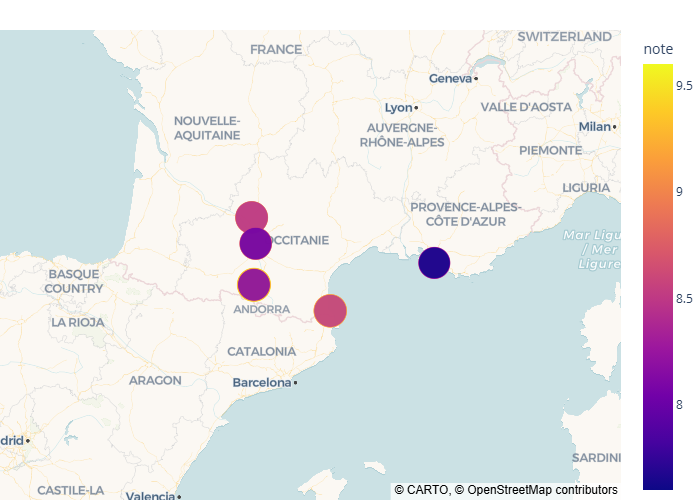

In [9]:
# Exécution du script complet cartes.py
%run scripts/cartes.py

visualiser_cartes_dataset_final(top_villes=5, top_hotels=20, save_files=False)
# Chemin vers ton PNG
png_path_1 = "data/top_villes.png"
png_path_2 = "data/top_hotels.png"

# Affichage dans le notebook
Image(filename=png_path_1)
Image(filename=png_path_2)